# MaizeGuard Rwanda — Final Capstone Model Notebook

**Project:** Machine Learning-Based Maize Grain Quality Assessment and Post-Harvest Recommendation System

This notebook is the clean capstone version. It prepares public maize/corn kernel datasets, trains a transfer-learning image model, evaluates the model with honest raw metrics, exports model files, and provides a deployment-ready prediction function for the web/API prototype.

## Target labels

| Label | Meaning |
|---|---|
| `good` | Clean maize/corn kernels suitable for normal storage or sale |
| `broken` | Broken or visibly damaged kernels |
| `impurity` | Foreign matter such as husks, stones, dust, or debris |
| `mold_risk` | Rotten or visually risky kernels; not laboratory-confirmed aflatoxin |

> Important: `mold_risk` is used instead of claiming confirmed mold/toxin contamination.

## What this notebook includes for the capstone

| ML Track requirement | Included here |
|---|---|
| Data visualization and data engineering | Dataset discovery, label mapping, duplicate removal, train/val/test split, class distribution, sample image grids, image-size summary, RGB summary |
| Model architecture | MobileNetV3 Large, ImageNet pretraining, classifier head, optimizer, loss function, training phases |
| Initial performance metrics | Accuracy, precision, recall, F1-score, classification report, confusion matrix, normalized confusion matrix, error samples |
| Deployment option | Exported `.pt`, `class_names.json`, API response format, Needs Review rule, frontend integration guidance |
| Diagrams | ML pipeline, system architecture, use case, sequence diagram, ERD-style data flow, deployment plan |
| Optional training improvement | CK-CNNLW synthetic crop augmentation, capped and added to training only |


In [1]:
# ============================================================
# 0. Install/import dependencies
# ============================================================

import sys
import subprocess
import importlib.util
from pathlib import Path

def ensure_package(package_name, import_name=None):
    import_name = import_name or package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

ensure_package("timm", "timm")

import os
import json
import math
import time
import shutil
import random
import hashlib
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance, ImageFilter, ImageOps

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("timm:", timm.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
timm: 1.0.26


In [2]:
# ============================================================
# 1. Configuration
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def choose_safe_device():
    """
    Kaggle's latest PyTorch builds may not support older GPUs such as Tesla P100
    because P100 has CUDA compute capability 6.0 (sm_60). If the installed PyTorch
    only supports sm_70+, trying to run a convolution on P100 causes:
    CUDA error: no kernel image is available for execution on the device.

    This function uses GPU only when the GPU is compatible. Otherwise it falls back
    to CPU so the notebook continues instead of crashing.
    """
    if not torch.cuda.is_available():
        print("[INFO] CUDA is not available. Using CPU.")
        return torch.device("cpu"), False

    try:
        gpu_name = torch.cuda.get_device_name(0)
        major, minor = torch.cuda.get_device_capability(0)
        capability = major + minor / 10
        print(f"[INFO] Detected GPU: {gpu_name} | CUDA capability: sm_{major}{minor}")

        if major < 7:
            print("[WARN] This GPU is older than sm_70. Kaggle's latest PyTorch often cannot run on it.")
            print("[WARN] Falling back to CPU to avoid: cudaErrorNoKernelImageForDevice.")
            print("[TIP] For GPU training, choose GPU T4 x2 instead of GPU P100 if Kaggle offers it.")
            return torch.device("cpu"), False

        # Run a tiny CUDA operation to confirm that CUDA really works.
        test = torch.randn(1, 3, 8, 8, device="cuda")
        conv = torch.nn.Conv2d(3, 4, 3).to("cuda")
        _ = conv(test)
        torch.cuda.synchronize()

        print("[INFO] CUDA test passed. Using GPU.")
        return torch.device("cuda"), True

    except Exception as e:
        print("[WARN] CUDA was detected but failed the safety test.")
        print("[WARN] Falling back to CPU. Error was:", repr(e))
        return torch.device("cpu"), False

DEVICE, CUDA_USABLE = choose_safe_device()

if CUDA_USABLE:
    torch.cuda.manual_seed_all(SEED)

print("Selected device:", DEVICE)

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working/maizeguard_public_training")
RAW_PUBLIC_ROOT = WORK_ROOT / "raw_public_sources"
READY_ROOT = WORK_ROOT / "maizeguard_ready_dataset"
OUTPUT_DIR = WORK_ROOT / "outputs"
DIAGRAM_DIR = WORK_ROOT / "diagrams"
EXTERNAL_TEST_DIR = WORK_ROOT / "real_external_test"

AUTO_DOWNLOAD_PUBLIC_DATASETS_IF_MISSING = True
CK_CNN_GIT_URL = "https://github.com/vision-cidis/CK-CNN.git"
CK_CNN_ZIP_URLS = [
    "https://github.com/vision-cidis/CK-CNN/archive/refs/heads/master.zip",
    "https://github.com/vision-cidis/CK-CNN/archive/refs/heads/main.zip",
]
CK_CNNLW_GIT_URL = "https://github.com/vision-cidis/CK-CNNLW.git"
CK_CNNLW_ZIP_URLS = [
    "https://github.com/vision-cidis/CK-CNNLW/archive/refs/heads/main.zip",
    "https://github.com/vision-cidis/CK-CNNLW/archive/refs/heads/master.zip",
]

for p in [WORK_ROOT, RAW_PUBLIC_ROOT, READY_ROOT, OUTPUT_DIR, DIAGRAM_DIR, EXTERNAL_TEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CLASSES = ["good", "broken", "impurity", "mold_risk"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

MAX_PER_CLASS = {
    "good": 3500,
    "broken": 3500,
    "impurity": 3500,
    "mold_risk": 3500,
}

ENABLE_TRAIN_ONLY_BROKEN_SYNTHETIC_AUGMENTATION = True
SYNTHETIC_BROKEN_MULTIPLIER = 2

MODEL_NAME = "mobilenetv3_large_100"

# Keep sizes safe for fallback CPU. If you use T4 GPU, the notebook uses higher resolution.
IMG_SIZE = 448 if DEVICE.type == "cuda" else 320
BATCH_SIZE = 16 if DEVICE.type == "cuda" else 8
NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0

HEAD_EPOCHS = 3 if DEVICE.type == "cuda" else 2
FINETUNE_EPOCHS = 18 if DEVICE.type == "cuda" else 8

LR_HEAD = 5e-4
LR_FINETUNE = 1.5e-5
WEIGHT_DECAY = 3e-4

OFFICIAL_EVAL_MODE = "raw argmax, single image pass, no threshold post-processing"

NEEDS_REVIEW_CONFIDENCE_BELOW = 0.65
NEEDS_REVIEW_TOP2_MARGIN_BELOW = 0.15

DATASET_HINTS = {
    "ck_cnn": ["ck-cnn", "ck_cnn", "ck-cnnlw", "ck_cnnlw", "corn-kernel", "corn_kernel", "kernel-classification"],
    "grainset": ["grainset", "grain-set", "grain_set"],
    "efficientmaize": ["efficientmaize", "efficient-maize", "maize-classification", "maize_seed", "maize-seed"],
    "grainbrain": ["grainbrain", "grain-brain", "grain_brain"],
}

CONFIG = {
    "model_backbone": MODEL_NAME,
    "pretraining": "ImageNet pretrained via timm",
    "input_image_size": IMG_SIZE,
    "classes": CLASSES,
    "loss": "cross_entropy",
    "label_smoothing": 0.0,
    "optimizer": "AdamW",
    "lr_head": LR_HEAD,
    "lr_finetune": LR_FINETUNE,
    "weight_decay": WEIGHT_DECAY,
    "official_evaluation": OFFICIAL_EVAL_MODE,
    "deployment_safety_rule": {
        "needs_review_confidence_below": NEEDS_REVIEW_CONFIDENCE_BELOW,
        "needs_review_top2_margin_below": NEEDS_REVIEW_TOP2_MARGIN_BELOW,
    },
    "training_only_synthetic_augmentation": ENABLE_TRAIN_ONLY_BROKEN_SYNTHETIC_AUGMENTATION,
    "synthetic_broken_multiplier": SYNTHETIC_BROKEN_MULTIPLIER,
    "selected_device": str(DEVICE),
    "cuda_usable": CUDA_USABLE,
}

with open(OUTPUT_DIR / "training_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

CONFIG


[INFO] Detected GPU: Tesla P100-PCIE-16GB | CUDA capability: sm_60
[WARN] This GPU is older than sm_70. Kaggle's latest PyTorch often cannot run on it.
[WARN] Falling back to CPU to avoid: cudaErrorNoKernelImageForDevice.
[TIP] For GPU training, choose GPU T4 x2 instead of GPU P100 if Kaggle offers it.
Selected device: cpu


{'model_backbone': 'mobilenetv3_large_100',
 'pretraining': 'ImageNet pretrained via timm',
 'input_image_size': 320,
 'classes': ['good', 'broken', 'impurity', 'mold_risk'],
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'optimizer': 'AdamW',
 'lr_head': 0.0005,
 'lr_finetune': 1.5e-05,
 'weight_decay': 0.0003,
 'official_evaluation': 'raw argmax, single image pass, no threshold post-processing',
 'deployment_safety_rule': {'needs_review_confidence_below': 0.65,
  'needs_review_top2_margin_below': 0.15},
 'training_only_synthetic_augmentation': True,
 'synthetic_broken_multiplier': 2,
 'selected_device': 'cpu',
 'cuda_usable': False}

# 2. Dataset preparation and label mapping

This section automatically discovers public datasets added through Kaggle's **Add Data** panel and maps them into the four MaizeGuard classes.

Recommended dataset priority:

1. **CK-CNN** — main supervised source for good, broken/defective, impurity, and rotten/mold-risk style corn kernel images.
2. **GrainSet maize** — useful support where labels can be mapped clearly.
3. **EfficientMaize** — useful only when labels are clear; avoid forcing broad `bad` into `mold_risk`.
4. **GrainBrain** — optional anomaly/good support; not the main supervised dataset.

The previous notebook tried to clone a non-existing/incorrect CK-CNN URL. This version uses the correct public repository URL, and if `git clone` fails it tries to download the GitHub ZIP archive.


In [3]:

# ============================================================
# 2. Dataset discovery, label mapping, split, and preparation
# ============================================================

import zipfile
import urllib.request
import subprocess
import shutil
from collections import Counter


def normalize_text(path: Path) -> str:
    return str(path).lower().replace("\\", "/").replace("-", "_").replace(" ", "_")


def is_image(path: Path) -> bool:
    return path.suffix.lower() in IMAGE_EXTENSIONS


def is_blocked_non_training_asset(path: Path) -> bool:
    text = normalize_text(path)

    # Do NOT block folder names like "individual/good".
    # Only block non-training files/folders.
    blocked_words = [
        "/.git/", "/figs/", "/models/", "/code/",
        "mask", "masks", "segmentation", "annotation", "annotations",
        "json", "xml", "readme", "metadata",
        "groundtruth", "ground_truth", "csv", "txt", "plot", "chart"
    ]

    return any(word in text for word in blocked_words)


def safe_open_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


def file_hash(path: Path) -> str:
    h = hashlib.sha1()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def list_input_folders(max_depth: int = 5):
    print("\n[DIAGNOSTIC] Existing folders under /kaggle/input and raw_public_sources:")
    roots = [KAGGLE_INPUT_ROOT, RAW_PUBLIC_ROOT, Path("/kaggle/working")]
    for root in roots:
        if not root.exists():
            print(f"  Missing: {root}")
            continue

        print(f"\n  Root: {root}")
        shown = 0
        for p in sorted(root.rglob("*")):
            if not p.is_dir():
                continue
            try:
                rel_depth = len(p.relative_to(root).parts)
            except Exception:
                rel_depth = 999
            if rel_depth <= max_depth:
                print("   ", p)
                shown += 1
            if shown >= 120:
                print("    ... stopped after 120 folders")
                break


def run_command(cmd, cwd=None):
    print("[CMD]", " ".join(map(str, cmd)))
    try:
        result = subprocess.run(
            cmd,
            cwd=str(cwd) if cwd else None,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            timeout=600,
        )
        print(result.stdout[-3000:])
        return result.returncode == 0
    except Exception as e:
        print("[WARN] Command failed:", repr(e))
        return False


def download_zip(url: str, destination: Path) -> bool:
    destination.parent.mkdir(parents=True, exist_ok=True)
    zip_path = destination.parent / f"{destination.name}.zip"

    try:
        print(f"[INFO] Downloading zip: {url}")
        urllib.request.urlretrieve(url, zip_path)

        tmp_dir = destination.parent / f"_{destination.name}_zip_extract"
        if tmp_dir.exists():
            shutil.rmtree(tmp_dir)
        tmp_dir.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(tmp_dir)

        extracted_dirs = [p for p in tmp_dir.iterdir() if p.is_dir()]
        if not extracted_dirs:
            print("[WARN] ZIP extracted but no folder was found.")
            return False

        if destination.exists():
            shutil.rmtree(destination)

        shutil.move(str(extracted_dirs[0]), str(destination))
        shutil.rmtree(tmp_dir)
        zip_path.unlink(missing_ok=True)

        print(f"[INFO] ZIP extracted to: {destination}")
        return True
    except Exception as e:
        print(f"[WARN] Zip download failed: {url}\n       {repr(e)}")
        return False


def clone_or_download_repo(repo_url: str, zip_urls: list[str], destination: Path) -> bool:
    """Clone a repo, with GitHub zip fallback."""
    if destination.exists():
        print(f"[INFO] Repo folder already exists: {destination}")
        return True

    destination.parent.mkdir(parents=True, exist_ok=True)

    ok = run_command(["git", "clone", "--depth", "1", repo_url, str(destination)])
    if ok and destination.exists():
        print(f"[INFO] Cloned repo to: {destination}")
        return True

    print("[WARN] git clone failed. Trying ZIP fallback...")
    for url in zip_urls:
        if download_zip(url, destination):
            return True

    return False


def ckcnn_individual_dir_exists(root: Path) -> bool:
    """Check whether the root has the classification folder we need."""
    possible = [
        root / "dataset" / "individual",
        root / "CK-CNN" / "dataset" / "individual",
        root / "CK-CNN-master" / "dataset" / "individual",
    ]

    for p in possible:
        if p.exists() and any(p.rglob("*")):
            return True

    # Generic deeper search, useful if Kaggle wraps repo folder name.
    for p in root.rglob("individual"):
        if p.is_dir() and (p / "good").exists() and ((p / "broken").exists() or (p / "defective").exists()):
            return True

    return False


def find_public_roots():
    """Find candidate roots. Prioritize CK-CNN because it has dataset/individual class folders."""
    roots = []

    search_roots = [KAGGLE_INPUT_ROOT, RAW_PUBLIC_ROOT, Path("/kaggle/working")]
    for base in search_roots:
        if not base.exists():
            continue

        for p in [base] + [x for x in base.rglob("*") if x.is_dir()]:
            name = p.name.lower()
            full = normalize_text(p)

            # Strong preference: actual classification dataset folder.
            if p.name == "individual" and (p / "good").exists():
                roots.append(p.parent.parent if len(p.parts) >= 2 else p)

            # Repo/folder hints.
            if any(h in full for h in ["ck_cnn", "ck-cnn", "ck_cnnlw", "ck-cnnlw", "corn_kernel", "corn-kernel", "grainset", "efficientmaize", "grainbrain"]):
                roots.append(p)

    # Always include raw public folders if they exist.
    for name in ["CK-CNN", "CK-CNN-master", "CK-CNNLW", "CK-CNNLW-main"]:
        p = RAW_PUBLIC_ROOT / name
        if p.exists():
            roots.append(p)

    # De-duplicate while preserving order.
    unique = []
    seen = set()
    for r in roots:
        key = str(r.resolve()) if r.exists() else str(r)
        if key not in seen:
            unique.append(r)
            seen.add(key)

    print("\n[INFO] Candidate dataset roots:")
    for r in unique[:80]:
        print(" ", r)
    if len(unique) > 80:
        print(f"  ... and {len(unique)-80} more")

    return unique


def download_ckcnn_if_needed():
    """Download the correct CK-CNN repo, not only CK-CNNLW.
    CK-CNNLW has cluster/synthesized images for segmentation, but CK-CNN has dataset/individual.
    """
    ckcnn_dest = RAW_PUBLIC_ROOT / "CK-CNN"
    if ckcnn_dest.exists() and ckcnn_individual_dir_exists(ckcnn_dest):
        print(f"[INFO] CK-CNN classification dataset already available: {ckcnn_dest}")
        return True

    # If an old incomplete CK-CNN folder exists without individual dataset, remove it.
    if ckcnn_dest.exists() and not ckcnn_individual_dir_exists(ckcnn_dest):
        print(f"[WARN] Removing incomplete CK-CNN folder: {ckcnn_dest}")
        shutil.rmtree(ckcnn_dest)

    print("[INFO] Downloading the correct CK-CNN repo with dataset/individual folders...")
    ok = clone_or_download_repo(CK_CNN_GIT_URL, CK_CNN_ZIP_URLS, ckcnn_dest)

    if ok and ckcnn_individual_dir_exists(ckcnn_dest):
        print("[INFO] CK-CNN dataset/individual detected successfully.")
        return True

    print("[WARN] CK-CNN download did not expose dataset/individual.")
    return False


def detect_dataset_name(path: Path) -> str:
    text = normalize_text(path)
    if "ck_cnn" in text or "ck-cnn" in text:
        return "ck_cnn"
    if "grainset" in text or "grain_set" in text or "grain-set" in text:
        return "grainset"
    if "efficientmaize" in text or "efficient_maize" in text or "efficient-maize" in text:
        return "efficientmaize"
    if "grainbrain" in text or "grain_brain" in text or "grain-brain" in text:
        return "grainbrain"
    return "unknown"


def detect_label_from_path(path: Path, dataset_name: str | None = None):
    text = normalize_text(path)

    if is_blocked_non_training_asset(path):
        return None

    # Very important:
    # CK-CNN repo has dataset/individual/good, broken, impurity, rotten folders.
    # CK-CNNLW repo has dataset/synthesized/train cluster images with annotations,
    # so those cluster images are NOT directly usable as class folders for this classifier.
    if "/dataset/synthesized/" in text or "/synthesized/" in text:
        return None

    parts = [x.lower().replace("-", "_").replace(" ", "_") for x in path.parts]

    # Exact folder-name mapping has priority.
    if "good" in parts or "healthy" in parts or "normal" in parts:
        return "good"

    if "impurity" in parts or "impurities" in parts:
        return "impurity"

    if "rotten" in parts or "rot" in parts or "mold" in parts or "mould" in parts or "mildew" in parts or "fungus" in parts:
        return "mold_risk"

    if "broken" in parts or "defective" in parts or "damaged" in parts or "damage" in parts or "defect" in parts:
        return "broken"

    # Fallback text matching for wrapped folder names.
    if "/good/" in text or "_good_" in text or "good_" in text:
        return "good"

    if "/impurity/" in text or "/impurities/" in text or "_impurity_" in text:
        return "impurity"

    if "/rotten/" in text or "_rotten_" in text or "mold" in text or "mould" in text or "mildew" in text or "fungus" in text:
        return "mold_risk"

    if "/broken/" in text or "_broken_" in text or "defective" in text or "damaged" in text:
        return "broken"

    return None


def collect_images_from_root(root: Path):
    records = []
    dataset_name = detect_dataset_name(root)

    if not root.exists():
        return records

    image_paths = [p for p in root.rglob("*") if p.is_file() and is_image(p)]
    if not image_paths:
        return records

    print(f"[INFO] Scanning {root} | images found: {len(image_paths)}")

    kept = 0
    examples = []

    for path in image_paths:
        label = detect_label_from_path(path, dataset_name)

        if label not in CLASSES:
            continue

        if not safe_open_image(path):
            continue

        records.append({
            "source_path": str(path),
            "label": label,
            "source_dataset": dataset_name,
            "is_synthetic": False,
        })

        kept += 1
        if len(examples) < 10:
            examples.append((label, str(path)))

    if kept:
        print(f"[INFO] Kept {kept} usable images from {root}")
        print("[INFO] Example mapped images:")
        for label, example_path in examples:
            print(f"  {label:10s} -> {example_path}")

    return records


def collect_public_records():
    # First download the correct CK-CNN if there is not already a usable classification dataset.
    roots_before = find_public_roots()
    initial_records = []
    for root in roots_before:
        initial_records.extend(collect_images_from_root(root))

    # If only CK-CNNLW/synthesized exists, initial_records will be empty.
    # Then download CK-CNN, which contains dataset/individual/good/broken/impurity/rotten.
    if not initial_records and AUTO_DOWNLOAD_PUBLIC_DATASETS_IF_MISSING:
        print("\n[INFO] No usable class-folder images found yet.")
        print("[INFO] Trying to download CK-CNN classification dataset automatically...")
        download_ckcnn_if_needed()

    roots = find_public_roots()
    records = []
    for root in roots:
        records.extend(collect_images_from_root(root))

    # De-duplicate same path records before hash duplicate removal.
    unique = []
    seen_paths = set()
    for r in records:
        if r["source_path"] not in seen_paths:
            unique.append(r)
            seen_paths.add(r["source_path"])
    records = unique

    if records:
        counts = Counter(r["label"] for r in records)
        print("\n[INFO] Raw collected label counts:")
        print(dict(counts))
        return records

    list_input_folders()
    raise RuntimeError(
        "No usable records were found. The notebook found CK-CNNLW synthesized cluster images, "
        "but those are segmentation images and not class-labeled folders. "
        "Fix: run this cell again after Restart Session, or manually add/clone the CK-CNN repo "
        "(https://github.com/vision-cidis/CK-CNN) so dataset/individual/good, broken, impurity, rotten exists."
    )


def remove_duplicate_records(records):
    print("\n[INFO] Removing duplicate images by SHA1 hash...")
    seen = set()
    unique = []

    for r in records:
        path = Path(r["source_path"])

        try:
            h = file_hash(path)
        except Exception:
            continue

        if h in seen:
            continue

        seen.add(h)
        unique.append({**r, "sha1": h})

    print(f"[INFO] Kept {len(unique)} unique images from {len(records)} records.")
    return unique


def limit_per_class(records):
    print("\n[INFO] Limiting max images per class for balanced training...")
    random.seed(SEED)
    output = []

    for label in CLASSES:
        items = [r for r in records if r["label"] == label]
        random.shuffle(items)

        max_n = MAX_PER_CLASS.get(label)
        if max_n is not None:
            items = items[:max_n]

        output.extend(items)
        print(f"  {label:10s}: {len(items)}")

    random.shuffle(output)
    return output


def split_records(records):
    print("\n[INFO] Creating train/val/test split...")
    random.seed(SEED)

    split_items = []

    for label in CLASSES:
        items = [r for r in records if r["label"] == label]
        random.shuffle(items)

        n = len(items)
        if n == 0:
            raise RuntimeError(f"No images found for class: {label}. Check dataset mapping.")

        train_end = int(n * TRAIN_RATIO)
        val_end = train_end + int(n * VAL_RATIO)

        # Ensure every class has test/val examples when possible.
        if n >= 10:
            train = items[:train_end]
            val = items[train_end:val_end]
            test = items[val_end:]
        else:
            train = items[:max(1, n - 2)]
            val = items[max(1, n - 2):max(1, n - 1)]
            test = items[max(1, n - 1):]

        for item in train:
            split_items.append({**item, "split": "train"})
        for item in val:
            split_items.append({**item, "split": "val"})
        for item in test:
            split_items.append({**item, "split": "test"})

        print(f"  {label:10s}: train={len(train)}, val={len(val)}, test={len(test)}")

    random.shuffle(split_items)
    return split_items


def prepare_ready_folders(split_items):
    print("\n[INFO] Preparing ImageFolder-compatible dataset...")
    if READY_ROOT.exists():
        shutil.rmtree(READY_ROOT)

    for split in ["train", "val", "test"]:
        for label in CLASSES:
            (READY_ROOT / split / label).mkdir(parents=True, exist_ok=True)

    final_records = []

    for idx, item in enumerate(split_items):
        src = Path(item["source_path"])
        split = item["split"]
        label = item["label"]
        ext = src.suffix.lower()
        dst = READY_ROOT / split / label / f"{item['source_dataset']}_{label}_{idx:06d}{ext}"

        # Use copy rather than symlink so Kaggle exports/downloads work reliably.
        shutil.copy2(src, dst)

        final_records.append({
            **item,
            "prepared_path": str(dst),
        })

    df = pd.DataFrame(final_records)
    df.to_csv(OUTPUT_DIR / "dataset_manifest.csv", index=False)

    with open(OUTPUT_DIR / "class_names.json", "w") as f:
        json.dump(CLASSES, f, indent=2)

    summary = (
        df.groupby(["split", "label"])
        .size()
        .reset_index(name="images")
        .sort_values(["label", "split"])
    )

    source_summary = (
        df.groupby(["source_dataset", "label"])
        .size()
        .reset_index(name="images")
        .sort_values(["source_dataset", "label"])
    )

    summary.to_csv(OUTPUT_DIR / "dataset_summary_by_split.csv", index=False)
    source_summary.to_csv(OUTPUT_DIR / "dataset_summary_by_source.csv", index=False)

    print("\n[SUMMARY] Split/label counts")
    print(summary.to_string(index=False))
    print("\n[SUMMARY] Source/label counts")
    print(source_summary.to_string(index=False))
    print("\n[INFO] Ready dataset:", READY_ROOT)

    return df


records = collect_public_records()
records = remove_duplicate_records(records)
records = limit_per_class(records)
split_items = split_records(records)
manifest_df = prepare_ready_folders(split_items)
manifest_df.head()



[INFO] Candidate dataset roots:
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNN
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNNLW
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNN/.git
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNN/code
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNN/figs
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNN/dataset
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNNLW/.git
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNNLW/figs
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNNLW/dataset
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNN/.git/objects
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNN/.git/refs
  /kaggle/working/maizeguard_public_training/raw_public_sources/CK-CNN/.git/logs
  /kaggle/working/maizeguard_publ

,source_path,label,source_dataset,is_synthetic,sha1,split,prepared_path
0,/kaggle/working/maizeguard_public_training/raw...,impurity,ck_cnn,False,a50615222f0306fdb2db1163fc2be5c2e6a190b3,test,/kaggle/working/maizeguard_public_training/mai...
1,/kaggle/working/maizeguard_public_training/raw...,impurity,ck_cnn,False,849b40c278a87ea41bd23eef239845b3dde6c388,test,/kaggle/working/maizeguard_public_training/mai...
2,/kaggle/working/maizeguard_public_training/raw...,broken,ck_cnn,False,212db655d98d3a561561848ae47120265e7dec79,train,/kaggle/working/maizeguard_public_training/mai...
3,/kaggle/working/maizeguard_public_training/raw...,good,ck_cnn,False,2c4feb92811644c81cae4b8f0ad27921ccb6cdb4,val,/kaggle/working/maizeguard_public_training/mai...
4,/kaggle/working/maizeguard_public_training/raw...,good,ck_cnn,False,32f0c8b24a780f3ef2ce754bd0b49171a0edb8fa,train,/kaggle/working/maizeguard_public_training/mai...


# 3. Training-only synthetic augmentation

The remaining difficult error is usually `broken → mold_risk`. To reduce this, the notebook creates **training-only** variations of broken kernels. These generated images are not used in validation or testing.

This is acceptable because augmentation is a normal machine learning technique, but it must be documented and kept out of the official test set.

In [4]:
# ============================================================
# 3. Training-only synthetic augmentation for broken class
# ============================================================

SYNTHETIC_AUDIT_PATH = OUTPUT_DIR / "training_only_synthetic_audit.csv"

def augment_broken_image(img: Image.Image) -> Image.Image:
    img = img.convert("RGB")
    angle = random.uniform(-14, 14)
    img = img.rotate(angle, expand=False, fillcolor=(245, 245, 240))
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.92, 1.12))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.92, 1.15))
    img = ImageEnhance.Sharpness(img).enhance(random.uniform(0.9, 1.25))
    if random.random() < 0.18:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.15, 0.45)))
    return img

def create_training_only_broken_synthetic():
    if not ENABLE_TRAIN_ONLY_BROKEN_SYNTHETIC_AUGMENTATION:
        print("[INFO] Synthetic broken augmentation disabled.")
        return pd.DataFrame()

    broken_train_dir = READY_ROOT / "train" / "broken"
    originals = [p for p in broken_train_dir.glob("*") if p.suffix.lower() in IMAGE_EXTENSIONS and "synthetic" not in p.name]

    if not originals:
        print("[WARN] No broken training images found for synthetic augmentation.")
        return pd.DataFrame()

    random.seed(SEED)
    audit = []

    for source in originals:
        for k in range(SYNTHETIC_BROKEN_MULTIPLIER):
            try:
                img = Image.open(source).convert("RGB")
                aug = augment_broken_image(img)

                new_path = broken_train_dir / f"synthetic_broken_{source.stem}_{k}.jpg"
                aug.save(new_path, quality=92)

                audit.append({
                    "source_path": str(source),
                    "synthetic_path": str(new_path),
                    "label": "broken",
                    "split": "train",
                    "purpose": "training_only_broken_augmentation",
                })
            except Exception as e:
                print("Skipped synthetic augmentation:", source, e)

    audit_df = pd.DataFrame(audit)
    audit_df.to_csv(SYNTHETIC_AUDIT_PATH, index=False)

    print(f"[INFO] Created {len(audit_df)} training-only synthetic broken images.")
    print(f"[INFO] Audit saved to: {SYNTHETIC_AUDIT_PATH}")
    return audit_df

synthetic_audit_df = create_training_only_broken_synthetic()
display(synthetic_audit_df.head() if not synthetic_audit_df.empty else synthetic_audit_df)

[INFO] Created 84 training-only synthetic broken images.
[INFO] Audit saved to: /kaggle/working/maizeguard_public_training/outputs/training_only_synthetic_audit.csv


,source_path,synthetic_path,label,split,purpose
0,/kaggle/working/maizeguard_public_training/mai...,/kaggle/working/maizeguard_public_training/mai...,broken,train,training_only_broken_augmentation
1,/kaggle/working/maizeguard_public_training/mai...,/kaggle/working/maizeguard_public_training/mai...,broken,train,training_only_broken_augmentation
2,/kaggle/working/maizeguard_public_training/mai...,/kaggle/working/maizeguard_public_training/mai...,broken,train,training_only_broken_augmentation
3,/kaggle/working/maizeguard_public_training/mai...,/kaggle/working/maizeguard_public_training/mai...,broken,train,training_only_broken_augmentation
4,/kaggle/working/maizeguard_public_training/mai...,/kaggle/working/maizeguard_public_training/mai...,broken,train,training_only_broken_augmentation


# 3.1 Optional CK-CNNLW synthesized crop augmentation

CK-CNNLW provides synthesized cluster images and VIA polygon annotations. A full cluster image contains many objects, so it must **not** be placed directly into one class folder. This cell crops each annotated object, maps labels into MaizeGuard classes, and adds a capped number of crops to the **training split only**.

Label mapping used here:

| CK-CNNLW annotation | MaizeGuard label |
|---|---|
| `good` | `good` |
| `defective` | `broken` |
| `others` | `impurity` |

This source does not provide a reliable `mold_risk` class, so it is not used for mold-risk training. Synthetic crops are useful for improving kernel-level recognition, but final testing must still use CK-CNN holdout and external/real phone-style images.


In [ ]:
# ============================================================
# 3.1 Optional CK-CNNLW synthesized crop augmentation
# ============================================================

from PIL import ImageDraw

ENABLE_CKCNNLW_SYNTHETIC_CROP_AUGMENTATION = True
CKCNNLW_SYNTHETIC_SOURCE_SPLITS = ["train"]  # keep validation synthetic images out of official validation/test metrics
CKCNNLW_SYNTHETIC_LIMITS = {
    "good": 600,
    "broken": 600,
    "impurity": 500,
    "mold_risk": 0,
}
CKCNNLW_SYNTHETIC_PADDING = 10
CKCNNLW_SYNTHETIC_MIN_SIZE = 24
CKCNNLW_SYNTHETIC_MASK_BACKGROUND = True
CKCNNLW_SYNTHETIC_AUDIT_PATH = OUTPUT_DIR / "ckcnnlw_synthetic_crop_audit.csv"
CKCNNLW_SYNTHETIC_SUMMARY_PATH = OUTPUT_DIR / "ckcnnlw_synthetic_crop_summary.json"


def normalize_ckcnnlw_label(value):
    text = str(value or "").strip().lower().replace("-", "_").replace(" ", "_")
    mapping = {
        "good": "good",
        "healthy": "good",
        "normal": "good",
        "defective": "broken",
        "defect": "broken",
        "broken": "broken",
        "damage": "broken",
        "damaged": "broken",
        "impurity": "impurity",
        "impurities": "impurity",
        "foreign": "impurity",
        "others": "impurity",
        "other": "impurity",
    }
    for key, mapped in mapping.items():
        if key in text:
            return mapped
    return None


def get_ckcnnlw_region_label(region):
    shape = region.get("shape_attributes", {})
    attrs = region.get("region_attributes", {})
    candidates = [
        shape.get("class_name"),
        attrs.get("class_name"),
        attrs.get("class"),
        attrs.get("label"),
        attrs.get("name"),
    ]
    for value in candidates:
        mapped = normalize_ckcnnlw_label(value)
        if mapped:
            return mapped
    return None


def ensure_ckcnnlw_repo():
    repo_dir = RAW_PUBLIC_ROOT / "CK-CNNLW"
    if (repo_dir / "dataset" / "synthesized").exists():
        print("[INFO] CK-CNNLW repo already available:", repo_dir)
        return repo_dir

    ok = clone_or_download_repo(CK_CNNLW_GIT_URL, CK_CNNLW_ZIP_URLS, repo_dir)
    if not ok:
        print("[WARN] Could not download CK-CNNLW. Skipping synthetic crop augmentation.")
        return None

    if not (repo_dir / "dataset" / "synthesized").exists():
        print("[WARN] CK-CNNLW downloaded, but dataset/synthesized was not found. Skipping.")
        return None

    return repo_dir


def iter_via_regions(annotation_data):
    for _, item in annotation_data.items():
        filename = item.get("filename")
        regions = item.get("regions", [])
        if isinstance(regions, dict):
            regions = regions.values()
        for region_index, region in enumerate(regions):
            yield filename, region_index, region


def crop_ckcnnlw_polygon(image, points_x, points_y):
    width, height = image.size
    min_x = max(min(points_x) - CKCNNLW_SYNTHETIC_PADDING, 0)
    min_y = max(min(points_y) - CKCNNLW_SYNTHETIC_PADDING, 0)
    max_x = min(max(points_x) + CKCNNLW_SYNTHETIC_PADDING, width - 1)
    max_y = min(max(points_y) + CKCNNLW_SYNTHETIC_PADDING, height - 1)

    if max_x <= min_x or max_y <= min_y:
        return None

    box = (int(min_x), int(min_y), int(max_x) + 1, int(max_y) + 1)
    crop = image.crop(box).convert("RGB")

    if not CKCNNLW_SYNTHETIC_MASK_BACKGROUND:
        return crop

    shifted_points = [(x - box[0], y - box[1]) for x, y in zip(points_x, points_y)]
    mask = Image.new("L", crop.size, 0)
    draw = ImageDraw.Draw(mask)
    draw.polygon(shifted_points, fill=255)

    background = Image.new("RGB", crop.size, (245, 245, 245))
    background.paste(crop, mask=mask)
    return background


def collect_ckcnnlw_regions(synth_root):
    candidates = []
    label_counts = Counter()
    skipped = Counter()

    for split in CKCNNLW_SYNTHETIC_SOURCE_SPLITS:
        split_root = synth_root / split
        annotation_path = split_root / "via_region_data.json"
        if not annotation_path.exists():
            skipped[f"{split}/missing_annotation"] += 1
            continue

        annotation_data = json.loads(annotation_path.read_text())
        for filename, region_index, region in iter_via_regions(annotation_data):
            label = get_ckcnnlw_region_label(region)
            if not label:
                skipped[f"{split}/unknown_label"] += 1
                continue
            if CKCNNLW_SYNTHETIC_LIMITS.get(label, 0) <= 0:
                skipped[f"{split}/{label}_disabled"] += 1
                continue

            shape = region.get("shape_attributes", {})
            points_x = shape.get("all_points_x") or []
            points_y = shape.get("all_points_y") or []
            if len(points_x) < 3 or len(points_y) < 3:
                skipped[f"{split}/invalid_polygon"] += 1
                continue

            image_path = split_root / filename
            if not image_path.exists():
                skipped[f"{split}/missing_image"] += 1
                continue

            label_counts[f"{split}/{label}"] += 1
            candidates.append({
                "split": split,
                "image_path": image_path,
                "filename": filename,
                "region_index": region_index,
                "label": label,
                "points_x": points_x,
                "points_y": points_y,
            })

    print("[INFO] CK-CNNLW annotated candidates by split/label:")
    print(dict(label_counts))
    if skipped:
        print("[INFO] CK-CNNLW skipped annotations:")
        print(dict(skipped))
    return candidates, skipped


def add_ckcnnlw_synthetic_crops_to_training():
    if not ENABLE_CKCNNLW_SYNTHETIC_CROP_AUGMENTATION:
        print("[INFO] CK-CNNLW synthetic crop augmentation disabled.")
        return pd.DataFrame()

    repo_dir = ensure_ckcnnlw_repo()
    if repo_dir is None:
        return pd.DataFrame()

    synth_root = repo_dir / "dataset" / "synthesized"
    candidates, skipped = collect_ckcnnlw_regions(synth_root)
    random.seed(SEED)
    random.shuffle(candidates)

    image_cache = {}
    used_counts = Counter()
    audit = []

    for item in candidates:
        label = item["label"]
        if used_counts[label] >= CKCNNLW_SYNTHETIC_LIMITS.get(label, 0):
            continue

        image_path = item["image_path"]
        try:
            if image_path not in image_cache:
                image_cache[image_path] = Image.open(image_path).convert("RGB")
            crop = crop_ckcnnlw_polygon(image_cache[image_path], item["points_x"], item["points_y"])
            if crop is None or min(crop.size) < CKCNNLW_SYNTHETIC_MIN_SIZE:
                skipped[f"{item['split']}/too_small"] += 1
                continue

            out_dir = READY_ROOT / "train" / label
            out_dir.mkdir(parents=True, exist_ok=True)
            out_path = out_dir / f"ckcnnlw_synth_{Path(item['filename']).stem}_{item['region_index']:04d}.jpg"
            crop.save(out_path, quality=92)

            used_counts[label] += 1
            audit.append({
                "source_dataset": "ckcnnlw_synthetic",
                "source_split": item["split"],
                "source_image": str(image_path),
                "prepared_path": str(out_path),
                "label": label,
                "split": "train",
                "width": crop.width,
                "height": crop.height,
                "purpose": "training_only_synthetic_crop_augmentation",
            })
        except Exception as e:
            skipped[f"{item['split']}/error"] += 1
            print("[WARN] Could not crop CK-CNNLW region:", image_path, e)

    audit_df = pd.DataFrame(audit)
    audit_df.to_csv(CKCNNLW_SYNTHETIC_AUDIT_PATH, index=False)

    summary = {
        "source": "https://github.com/vision-cidis/CK-CNNLW",
        "used_counts": dict(used_counts),
        "limits": CKCNNLW_SYNTHETIC_LIMITS,
        "skipped": dict(skipped),
        "note": "Added to train split only. Do not use CK-CNNLW synthetic crops as official validation/test metrics.",
    }
    with open(CKCNNLW_SYNTHETIC_SUMMARY_PATH, "w") as f:
        json.dump(summary, f, indent=2)

    print("[INFO] Added CK-CNNLW synthetic crops to READY_ROOT/train:")
    print(summary)
    print("[INFO] Audit saved to:", CKCNNLW_SYNTHETIC_AUDIT_PATH)
    print("[INFO] Summary saved to:", CKCNNLW_SYNTHETIC_SUMMARY_PATH)
    return audit_df

ckcnnlw_synthetic_audit_df = add_ckcnnlw_synthetic_crops_to_training()
display(ckcnnlw_synthetic_audit_df.head() if not ckcnnlw_synthetic_audit_df.empty else ckcnnlw_synthetic_audit_df)


# 3.2 Synthetic batch images for upload-style robustness

The CK-CNNLW figures show why this matters: real uploads often contain many kernels in one photo, while many public datasets contain single kernels. The modern version used here keeps the pipeline simple:

1. Crop annotated CK-CNNLW synthetic objects.
2. Add capped crops to training only.
3. Use full-image-plus-tile inference in FastAPI for uploaded batch photos.

I am not copying the old six-year-old TensorFlow/Mask R-CNN code. Instead, the notebook keeps PyTorch/MobileNetV3 and uses synthetic crops plus deployment tiling to improve robustness efficiently.


# 4. Data visualization and engineering checks

These plots are useful for the video and notebook submission.

Manifest columns: ['source_path', 'label', 'source_dataset', 'is_synthetic', 'sha1', 'split', 'prepared_path']


,split,label,images
0,train,good,84
1,train,broken,126
2,train,impurity,35
3,train,mold_risk,42
4,val,good,18
5,val,broken,9
6,val,impurity,7
7,val,mold_risk,9
8,test,good,18
9,test,broken,9


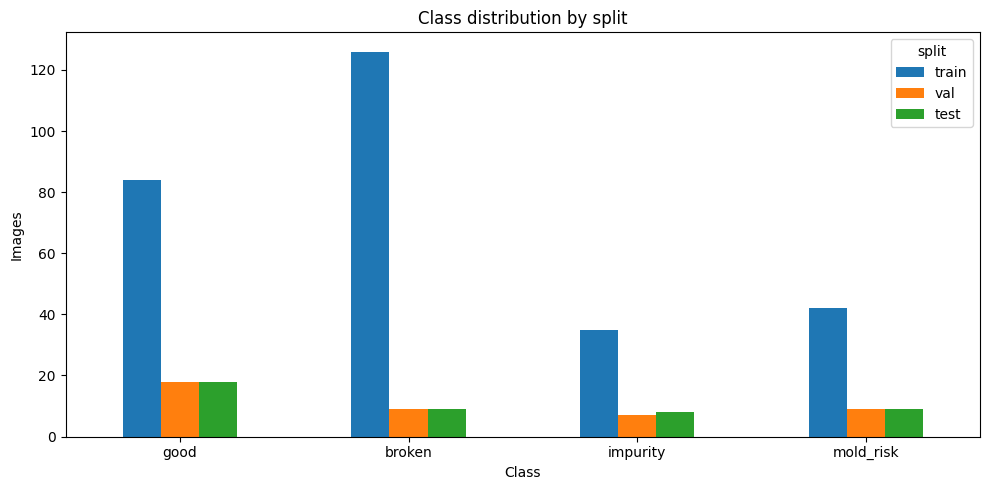

,dataset,label,images
0,ck_cnn,broken,60
1,ck_cnn,good,120
2,ck_cnn,impurity,50
3,ck_cnn,mold_risk,60


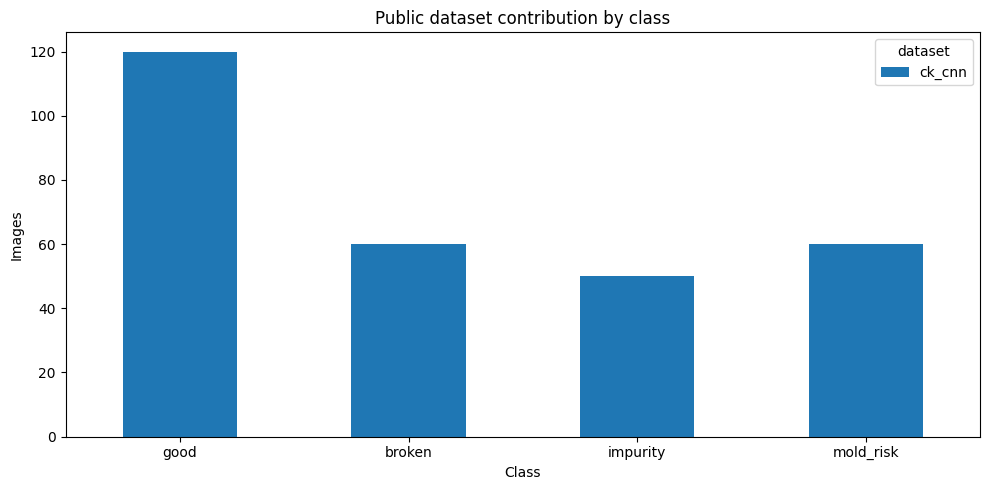

In [5]:
# ============================================================
# 4. Data visualization
# ============================================================

# This cell is robust to manifest column names.
# Some notebook versions save the source column as "source_dataset",
# while older plot code expected "dataset". This fixes the KeyError.

print("Manifest columns:", list(manifest_df.columns))

if "dataset" not in manifest_df.columns:
    if "source_dataset" in manifest_df.columns:
        manifest_df["dataset"] = manifest_df["source_dataset"]
    elif "source" in manifest_df.columns:
        manifest_df["dataset"] = manifest_df["source"]
    else:
        manifest_df["dataset"] = "ck_cnn"

if "label" not in manifest_df.columns:
    if "class" in manifest_df.columns:
        manifest_df["label"] = manifest_df["class"]
    elif "target" in manifest_df.columns:
        manifest_df["label"] = manifest_df["target"]
    else:
        raise KeyError("manifest_df must contain a label/class/target column.")

manifest_df["dataset"] = manifest_df["dataset"].fillna("ck_cnn").astype(str)
manifest_df["label"] = manifest_df["label"].astype(str)


def count_imagefolder(root: Path):
    rows = []
    for split in ["train", "val", "test"]:
        for label in CLASSES:
            d = root / split / label
            n = len([p for p in d.glob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]) if d.exists() else 0
            rows.append({"split": split, "label": label, "images": n})
    return pd.DataFrame(rows)


dist_df = count_imagefolder(READY_ROOT)
display(dist_df)

# Plot 1: train/val/test distribution
pivot = (
    dist_df.pivot(index="label", columns="split", values="images")
    .fillna(0)
    .reindex(CLASSES)
)
for col in ["train", "val", "test"]:
    if col not in pivot.columns:
        pivot[col] = 0

ax = pivot[["train", "val", "test"]].plot(kind="bar", figsize=(10, 5))
ax.set_title("Class distribution by split")
ax.set_ylabel("Images")
ax.set_xlabel("Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_class_distribution_by_split.png", dpi=180)
plt.show()

# Plot 2: source dataset contribution by class
source_plot_df = (
    manifest_df.groupby(["dataset", "label"])
    .size()
    .reset_index(name="images")
)

display(source_plot_df)

if not source_plot_df.empty:
    source_pivot = (
        source_plot_df.pivot(index="label", columns="dataset", values="images")
        .fillna(0)
        .reindex(CLASSES)
    )
    ax = source_pivot.plot(kind="bar", stacked=True, figsize=(10, 5))
    ax.set_title("Public dataset contribution by class")
    ax.set_ylabel("Images")
    ax.set_xlabel("Class")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "02_dataset_contribution_by_class.png", dpi=180)
    plt.show()
else:
    print("No source contribution plot because manifest_df is empty.")


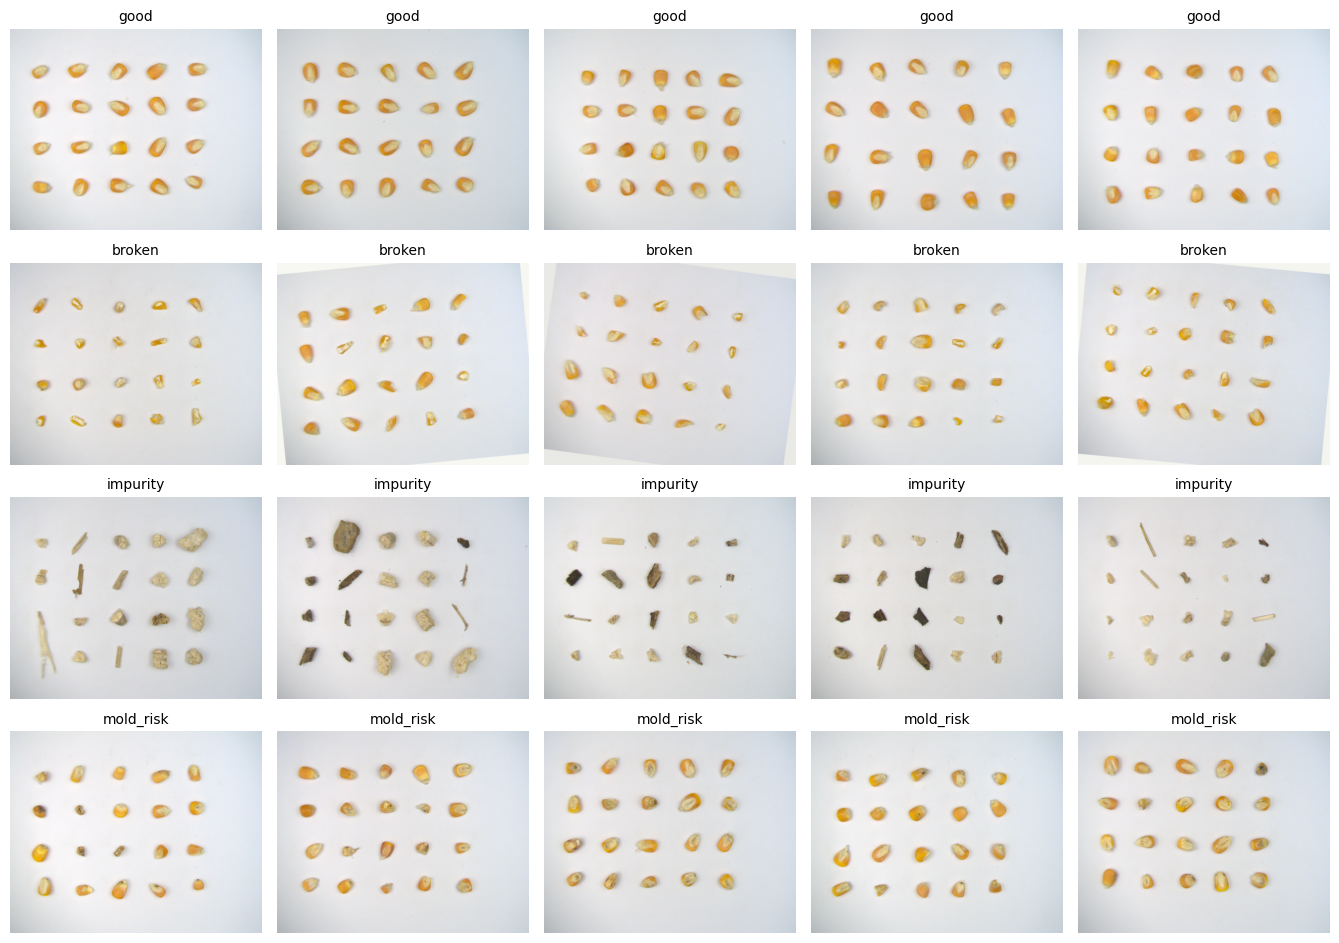

In [6]:
# Sample images by class

def show_sample_grid(root=READY_ROOT, split="train", per_class=5):
    fig, axes = plt.subplots(len(CLASSES), per_class, figsize=(per_class * 2.7, len(CLASSES) * 2.4))

    for row, label in enumerate(CLASSES):
        class_dir = root / split / label
        paths = [p for p in class_dir.glob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
        random.Random(SEED + row).shuffle(paths)
        sample_paths = paths[:per_class]

        for col in range(per_class):
            ax = axes[row, col]
            ax.axis("off")
            if col < len(sample_paths):
                img = Image.open(sample_paths[col]).convert("RGB")
                ax.imshow(img)
                ax.set_title(label, fontsize=10)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "03_sample_images_by_class.png", dpi=180)
    plt.show()

show_sample_grid()

,label,width,height,red_mean,green_mean,blue_mean
0,good,1280,1024,0.896474,0.888780,0.879328
1,good,1280,1024,0.838366,0.836227,0.822200
2,good,1280,1024,0.869106,0.862575,0.849266
3,good,1280,1024,0.872623,0.863140,0.851697
4,good,1280,1024,0.888503,0.884441,0.879416


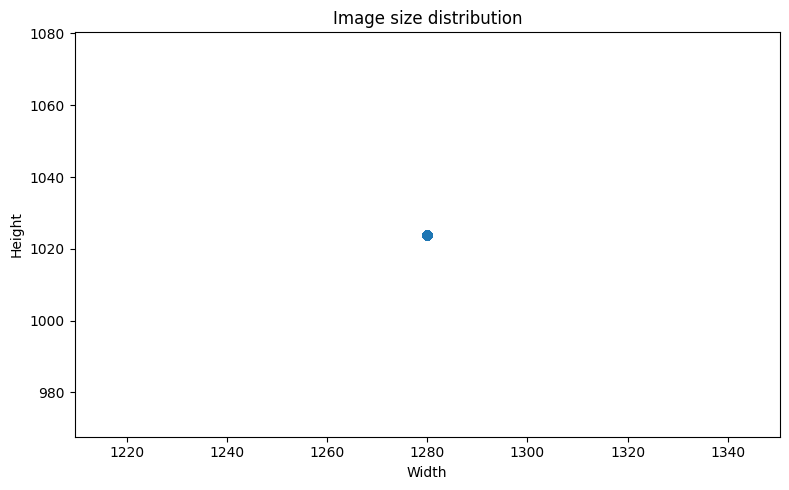

,red_mean,green_mean,blue_mean
label,,,
good,0.865318,0.861480,0.851405
broken,0.882497,0.879585,0.870952
impurity,0.851655,0.849336,0.847170
mold_risk,0.874710,0.872054,0.865411


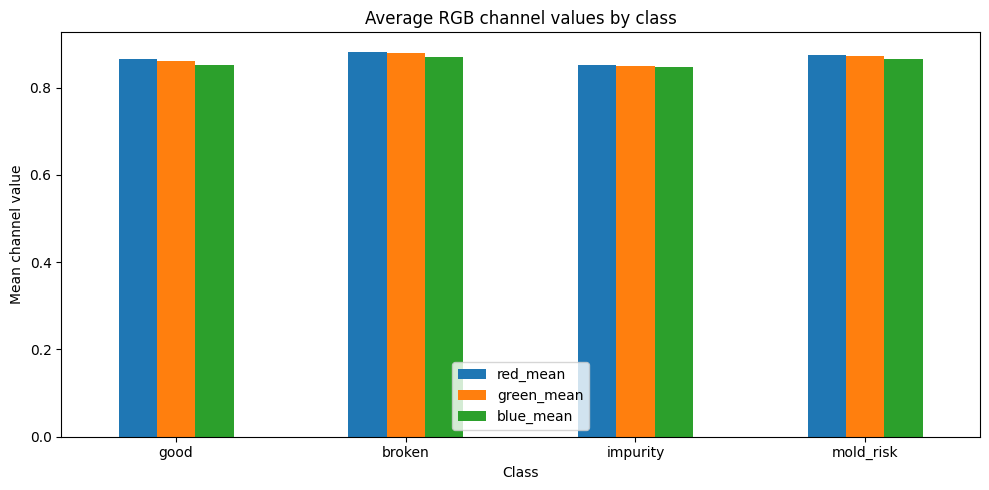

In [7]:
# Image size and RGB summary

def image_stats(root=READY_ROOT, split="train", max_per_class=250):
    rows = []
    for label in CLASSES:
        paths = [p for p in (root / split / label).glob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
        random.Random(SEED).shuffle(paths)
        paths = paths[:max_per_class]
        for p in paths:
            try:
                img = Image.open(p).convert("RGB")
                arr = np.asarray(img).astype(np.float32) / 255.0
                rows.append({
                    "label": label,
                    "width": img.width,
                    "height": img.height,
                    "red_mean": arr[:, :, 0].mean(),
                    "green_mean": arr[:, :, 1].mean(),
                    "blue_mean": arr[:, :, 2].mean(),
                })
            except Exception:
                pass
    return pd.DataFrame(rows)

stats_df = image_stats()
display(stats_df.head())

if not stats_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(stats_df["width"], stats_df["height"], alpha=0.35)
    ax.set_title("Image size distribution")
    ax.set_xlabel("Width")
    ax.set_ylabel("Height")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "04_image_size_distribution.png", dpi=180)
    plt.show()

    rgb_summary = stats_df.groupby("label")[["red_mean", "green_mean", "blue_mean"]].mean().reindex(CLASSES)
    display(rgb_summary)

    ax = rgb_summary.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Average RGB channel values by class")
    ax.set_ylabel("Mean channel value")
    ax.set_xlabel("Class")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_rgb_summary_by_class.png", dpi=180)
    plt.show()

# 5. Dataset and model classes

The model uses transfer learning. The base CNN already learned general image features from ImageNet. The final classifier is adapted to four MaizeGuard classes.

In [8]:
# ============================================================
# 5. Dataset and dataloaders
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(degrees=12, fill=(245, 245, 240)),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

class MaizeImageDataset(Dataset):
    def __init__(self, root: Path, split: str, transform=None):
        self.root = root
        self.split = split
        self.transform = transform
        self.samples = []

        for label in CLASSES:
            class_dir = root / split / label
            if not class_dir.exists():
                continue
            for path in class_dir.glob("*"):
                if path.suffix.lower() in IMAGE_EXTENSIONS:
                    self.samples.append((path, CLASS_TO_IDX[label]))

        if not self.samples:
            raise RuntimeError(f"No images found in {root}/{split}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, y = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, y, str(path)

train_ds = MaizeImageDataset(READY_ROOT, "train", train_transform)
val_ds = MaizeImageDataset(READY_ROOT, "val", eval_transform)
test_ds = MaizeImageDataset(READY_ROOT, "test", eval_transform)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))
print("Classes:", CLASSES)

def make_weighted_sampler(dataset):
    labels = [y for _, y in dataset.samples]
    counts = Counter(labels)
    weights = [1.0 / counts[y] for y in labels]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

USE_WEIGHTED_SAMPLER = True
train_sampler = make_weighted_sampler(train_ds) if USE_WEIGHTED_SAMPLER else None

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(train_sampler is None),
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

print("Using weighted sampler:", USE_WEIGHTED_SAMPLER)

Train: 287 Val: 43 Test: 44
Classes: ['good', 'broken', 'impurity', 'mold_risk']
Using weighted sampler: True


In [9]:
# ============================================================
# 6. Model architecture
# ============================================================

def build_model(model_name=MODEL_NAME, num_classes=len(CLASSES)):
    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=num_classes,
    )
    return model

model = build_model()
model = model.to(DEVICE)

# Save the full architecture text without flooding the notebook output.
architecture_text = str(model)
with open(OUTPUT_DIR / "model_architecture_full.txt", "w") as f:
    f.write(architecture_text)

print(f"Model created on device: {DEVICE}")
print(f"Full model architecture saved to: {OUTPUT_DIR / 'model_architecture_full.txt'}")
print("Classifier layer:")
print(model.get_classifier() if hasattr(model, "get_classifier") else "Classifier summary unavailable")

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

arch_summary = pd.DataFrame([
    {"item": "Backbone", "value": MODEL_NAME},
    {"item": "Pretraining", "value": "ImageNet via timm"},
    {"item": "Input image size", "value": IMG_SIZE},
    {"item": "Classes", "value": ", ".join(CLASSES)},
    {"item": "Optimizer", "value": "AdamW"},
    {"item": "Loss", "value": "CrossEntropyLoss"},
    {"item": "Label smoothing", "value": 0.0},
    {"item": "Device used", "value": str(DEVICE)},
    {"item": "CUDA usable", "value": CUDA_USABLE},
    {"item": "Total parameters", "value": num_params},
    {"item": "Trainable parameters", "value": trainable_params},
])
display(arch_summary)
arch_summary.to_csv(OUTPUT_DIR / "model_architecture_summary.csv", index=False)


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

Model created on device: cpu
Full model architecture saved to: /kaggle/working/maizeguard_public_training/outputs/model_architecture_full.txt
Classifier layer:
Linear(in_features=1280, out_features=4, bias=True)


,item,value
0,Backbone,mobilenetv3_large_100
1,Pretraining,ImageNet via timm
2,Input image size,320
3,Classes,"good, broken, impurity, mold_risk"
4,Optimizer,AdamW
5,Loss,CrossEntropyLoss
6,Label smoothing,0.0
7,Device used,cpu
8,CUDA usable,False
9,Total parameters,4207156


# 6.1 Model architecture explanation for video

The model uses **MobileNetV3 Large** as a transfer-learning backbone. It is suitable for the capstone because it is smaller than many large CNNs but still performs strongly on image classification. The final classifier layer is replaced with four outputs: `good`, `broken`, `impurity`, and `mold_risk`.

The notebook trains in two phases:

1. **Head training** — train only the final classifier first.
2. **Fine-tuning** — unfreeze the full model and train with a small learning rate.

In [10]:
# ============================================================
# 7. Training functions
# ============================================================

def set_trainable(model, trainable: bool):
    for p in model.parameters():
        p.requires_grad = trainable

@torch.no_grad()
def evaluate_basic(model, loader, criterion):
    model.eval()
    losses = []
    ys = []
    preds = []

    for x, y, _ in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        losses.append(loss.item())
        ys.extend(y.cpu().numpy().tolist())
        preds.extend(logits.argmax(dim=1).cpu().numpy().tolist())

    acc = accuracy_score(ys, preds)
    _, _, f1, _ = precision_recall_fscore_support(ys, preds, average="macro", zero_division=0)
    return float(np.mean(losses)), float(acc), float(f1)

def train_one_phase(model, phase_name, train_loader, val_loader, epochs, lr, train_backbone):
    if train_backbone:
        set_trainable(model, True)
    else:
        set_trainable(model, False)
        for name, p in model.named_parameters():
            if any(key in name.lower() for key in ["classifier", "head", "fc"]):
                p.requires_grad = True

    trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[INFO] Phase={phase_name} | Trainable parameters={trainable_count:,} | Device={DEVICE}")

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=WEIGHT_DECAY,
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=0.0)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))

    # AMP is only enabled when CUDA passed the compatibility safety test.
    use_amp = DEVICE.type == "cuda" and CUDA_USABLE
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp) if use_amp else None

    phase_logs = []
    best_state = None
    best_val_f1 = -1

    for epoch in range(1, epochs + 1):
        start = time.time()
        model.train()
        train_losses = []

        for x, y, _ in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            if use_amp and scaler is not None:
                with torch.amp.autocast("cuda", enabled=True):
                    logits = model(x)
                    loss = criterion(logits, y)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(x)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()

            train_losses.append(loss.item())

        scheduler.step()
        val_loss, val_acc, val_macro_f1 = evaluate_basic(model, val_loader, criterion)

        log = {
            "phase": phase_name,
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": float(np.mean(train_losses)),
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_macro_f1": val_macro_f1,
            "seconds": round(time.time() - start, 2),
            "device": str(DEVICE),
        }
        print(log)
        phase_logs.append(log)

        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    return phase_logs, best_state, best_val_f1

# Rebuild model for training after architecture display.
model = build_model().to(DEVICE)
training_logs = []

try:
    head_logs, head_best_state, head_best_f1 = train_one_phase(
        model,
        phase_name="head",
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=HEAD_EPOCHS,
        lr=LR_HEAD,
        train_backbone=False,
    )
    training_logs.extend(head_logs)

    if head_best_state is not None:
        model.load_state_dict(head_best_state)

    finetune_logs, finetune_best_state, finetune_best_f1 = train_one_phase(
        model,
        phase_name="finetune",
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=FINETUNE_EPOCHS,
        lr=LR_FINETUNE,
        train_backbone=True,
    )
    training_logs.extend(finetune_logs)

except RuntimeError as e:
    error_text = str(e)
    if "no kernel image is available" in error_text or "cudaErrorNoKernelImageForDevice" in error_text:
        raise RuntimeError(
            "Your selected Kaggle GPU is not compatible with the installed PyTorch CUDA build. "
            "Choose GPU T4 x2, or use the fixed notebook device cell which automatically falls back to CPU. "
            "Restart the Kaggle session and run all cells from the top."
        ) from e
    raise

if "finetune_best_state" in globals() and finetune_best_state is not None:
    model.load_state_dict(finetune_best_state)

logs_df = pd.DataFrame(training_logs)
display(logs_df)
logs_df.to_csv(OUTPUT_DIR / "training_logs.csv", index=False)

best_model_path = OUTPUT_DIR / f"{MODEL_NAME}_best.pt"
torch.save({
    "model_name": MODEL_NAME,
    "state_dict": model.state_dict(),
    "classes": CLASSES,
    "img_size": IMG_SIZE,
    "config": CONFIG,
}, best_model_path)

print("Saved best model:", best_model_path)


[INFO] Phase=head | Trainable parameters=1,235,204 | Device=cpu
{'phase': 'head', 'epoch': 1, 'lr': 0.00025, 'train_loss': 2.0091721093178623, 'val_loss': 0.4926327895373106, 'val_accuracy': 0.7441860465116279, 'val_macro_f1': 0.7803724053724054, 'seconds': 24.54, 'device': 'cpu'}
{'phase': 'head', 'epoch': 2, 'lr': 0.0, 'train_loss': 0.7746901080908073, 'val_loss': 0.20286683551967144, 'val_accuracy': 0.8837209302325582, 'val_macro_f1': 0.8877990430622009, 'seconds': 22.21, 'device': 'cpu'}
[INFO] Phase=finetune | Trainable parameters=4,207,156 | Device=cpu
{'phase': 'finetune', 'epoch': 1, 'lr': 1.4429096493834651e-05, 'train_loss': 0.4030336918949615, 'val_loss': 0.09219580508458118, 'val_accuracy': 0.9767441860465116, 'val_macro_f1': 0.9721362229102167, 'seconds': 44.13, 'device': 'cpu'}
{'phase': 'finetune', 'epoch': 2, 'lr': 1.2803300858899106e-05, 'train_loss': 0.3755186954933581, 'val_loss': 0.07275921044250329, 'val_accuracy': 0.9767441860465116, 'val_macro_f1': 0.972136222910

,phase,epoch,lr,train_loss,val_loss,val_accuracy,val_macro_f1,seconds,device
0,head,1,2.500000e-04,2.009172,0.492633,0.744186,0.780372,24.54,cpu
1,head,2,0.000000e+00,0.774690,0.202867,0.883721,0.887799,22.21,cpu
2,finetune,1,1.442910e-05,0.403034,0.092196,0.976744,0.972136,44.13,cpu
3,finetune,2,1.280330e-05,0.375519,0.072759,0.976744,0.972136,45.53,cpu
4,finetune,3,1.037013e-05,0.428968,0.070984,0.976744,0.972136,45.57,cpu
5,finetune,4,7.500000e-06,0.305073,0.087028,0.953488,0.953151,45.19,cpu
6,finetune,5,4.629874e-06,0.235063,0.161446,0.930233,0.932516,46.01,cpu
7,finetune,6,2.196699e-06,0.282064,0.077417,0.976744,0.972136,44.87,cpu
8,finetune,7,5.709035e-07,0.350034,0.118408,0.953488,0.958978,44.27,cpu
9,finetune,8,0.000000e+00,0.198685,0.085330,0.953488,0.953151,44.71,cpu


Saved best model: /kaggle/working/maizeguard_public_training/outputs/mobilenetv3_large_100_best.pt


# 8. Training plots

These show whether the model is learning. Good signs include decreasing loss and stable/high validation accuracy and macro F1.

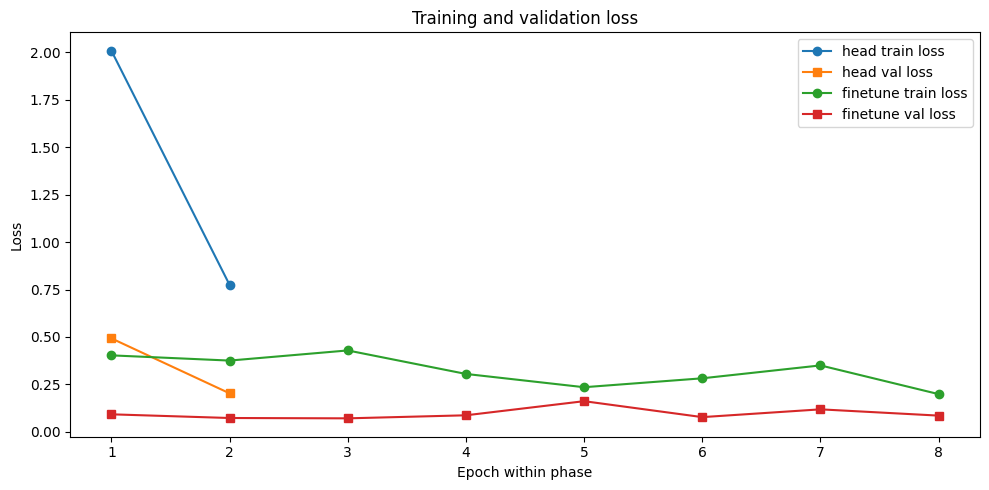

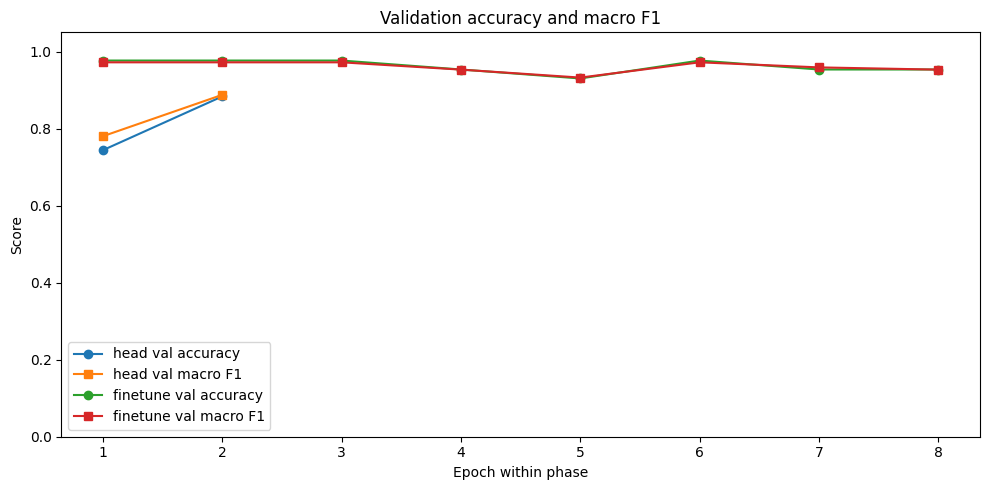

In [11]:
# ============================================================
# 8. Training visualization
# ============================================================

if not logs_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    for phase in logs_df["phase"].unique():
        sub = logs_df[logs_df["phase"] == phase]
        ax.plot(sub["epoch"], sub["train_loss"], marker="o", label=f"{phase} train loss")
        ax.plot(sub["epoch"], sub["val_loss"], marker="s", label=f"{phase} val loss")

    ax.set_title("Training and validation loss")
    ax.set_xlabel("Epoch within phase")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_training_validation_loss.png", dpi=180)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    for phase in logs_df["phase"].unique():
        sub = logs_df[logs_df["phase"] == phase]
        ax.plot(sub["epoch"], sub["val_accuracy"], marker="o", label=f"{phase} val accuracy")
        ax.plot(sub["epoch"], sub["val_macro_f1"], marker="s", label=f"{phase} val macro F1")

    ax.set_title("Validation accuracy and macro F1")
    ax.set_xlabel("Epoch within phase")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "07_validation_accuracy_macro_f1.png", dpi=180)
    plt.show()

In [12]:
# ============================================================
# 9. Official evaluation: raw argmax only
# ============================================================

@torch.no_grad()
def predict_loader_raw(model, loader):
    model.eval()
    y_true, y_pred, y_prob, paths = [], [], [], []

    for x, y, batch_paths in loader:
        x = x.to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        y_true.extend(y.numpy().tolist())
        y_pred.extend(preds.tolist())
        y_prob.extend(probs.tolist())
        paths.extend(list(batch_paths))

    return np.array(y_true), np.array(y_pred), np.array(y_prob), paths

y_true, y_pred, y_prob, test_paths = predict_loader_raw(model, test_loader)

acc = accuracy_score(y_true, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)

print("Final evaluation mode:", OFFICIAL_EVAL_MODE)
print(f"Accuracy: {acc:.4f}")
print(f"Macro precision: {precision_macro:.4f}")
print(f"Macro recall: {recall_macro:.4f}")
print(f"Macro F1: {f1_macro:.4f}")

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASSES,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)
report_df.to_csv(OUTPUT_DIR / "classification_report_raw_argmax.csv")

metrics_summary = pd.DataFrame([{
    "model": MODEL_NAME,
    "device": str(DEVICE),
    "evaluation_mode": OFFICIAL_EVAL_MODE,
    "accuracy": acc,
    "macro_precision": precision_macro,
    "macro_recall": recall_macro,
    "macro_f1": f1_macro,
    "test_samples": len(y_true),
    "mistakes": int((y_true != y_pred).sum()),
    "model_path": str(best_model_path),
}])
display(metrics_summary)
metrics_summary.to_csv(OUTPUT_DIR / "model_metrics_summary.csv", index=False)

records = []
for i, (true_i, pred_i, probs, path) in enumerate(zip(y_true, y_pred, y_prob, test_paths)):
    sorted_probs = np.sort(probs)[::-1]
    margin = float(sorted_probs[0] - sorted_probs[1]) if len(sorted_probs) > 1 else float(sorted_probs[0])
    row = {
        "path": path,
        "true_label": IDX_TO_CLASS[int(true_i)],
        "pred_label": IDX_TO_CLASS[int(pred_i)],
        "confidence": float(probs[pred_i]),
        "top2_margin": margin,
        "correct": bool(true_i == pred_i),
    }
    for idx, cls in IDX_TO_CLASS.items():
        row[f"prob_{cls}"] = float(probs[idx])
    records.append(row)

pred_df = pd.DataFrame(records)
pred_df.to_csv(OUTPUT_DIR / "test_predictions_and_errors_raw_argmax.csv", index=False)
display(pred_df.head())

mistakes_df = pred_df[pred_df["correct"] == False]
display(mistakes_df)
print(f"Mistakes: {len(mistakes_df)} / {len(pred_df)}")

Final evaluation mode: raw argmax, single image pass, no threshold post-processing
Accuracy: 0.9773
Macro precision: 0.9750
Macro recall: 0.9722
Macro F1: 0.9721


,precision,recall,f1-score,support
good,1.000000,1.000000,1.000000,18.000000
broken,1.000000,0.888889,0.941176,9.000000
impurity,1.000000,1.000000,1.000000,8.000000
mold_risk,0.900000,1.000000,0.947368,9.000000
accuracy,0.977273,0.977273,0.977273,0.977273
macro avg,0.975000,0.972222,0.972136,44.000000
weighted avg,0.979545,0.977273,0.977202,44.000000


,model,device,evaluation_mode,accuracy,macro_precision,macro_recall,macro_f1,test_samples,mistakes,model_path
0,mobilenetv3_large_100,cpu,"raw argmax, single image pass, no threshold po...",0.977273,0.975,0.972222,0.972136,44,1,/kaggle/working/maizeguard_public_training/out...


,path,true_label,pred_label,confidence,top2_margin,correct,prob_good,prob_broken,prob_impurity,prob_mold_risk
0,/kaggle/working/maizeguard_public_training/mai...,good,good,0.979046,0.962465,True,0.979046,0.016581,3.970881e-09,0.004373
1,/kaggle/working/maizeguard_public_training/mai...,good,good,0.995604,0.992105,True,0.995604,0.000898,1.398076e-10,0.003498
2,/kaggle/working/maizeguard_public_training/mai...,good,good,0.945715,0.897287,True,0.945715,0.048429,3.446832e-09,0.005856
3,/kaggle/working/maizeguard_public_training/mai...,good,good,0.989561,0.983470,True,0.989561,0.006091,4.888317e-11,0.004348
4,/kaggle/working/maizeguard_public_training/mai...,good,good,0.998190,0.997189,True,0.998190,0.001000,6.341243e-11,0.000810


,path,true_label,pred_label,confidence,top2_margin,correct,prob_good,prob_broken,prob_impurity,prob_mold_risk
18,/kaggle/working/maizeguard_public_training/mai...,broken,mold_risk,0.7283,0.52487,False,0.20343,0.06827,6.637135e-10,0.7283


Mistakes: 1 / 44


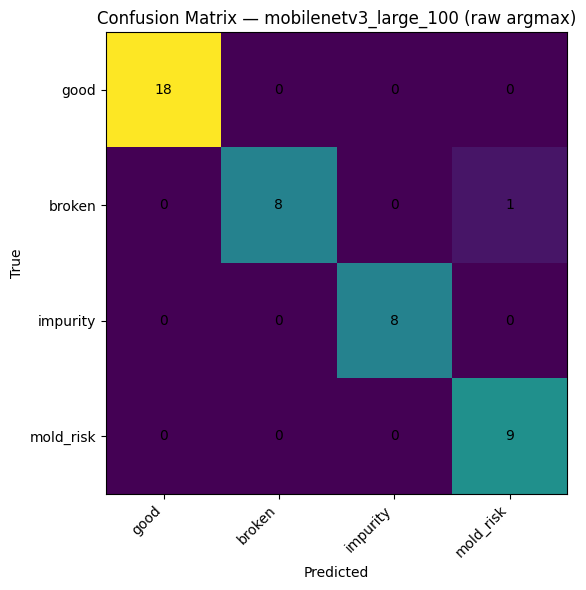

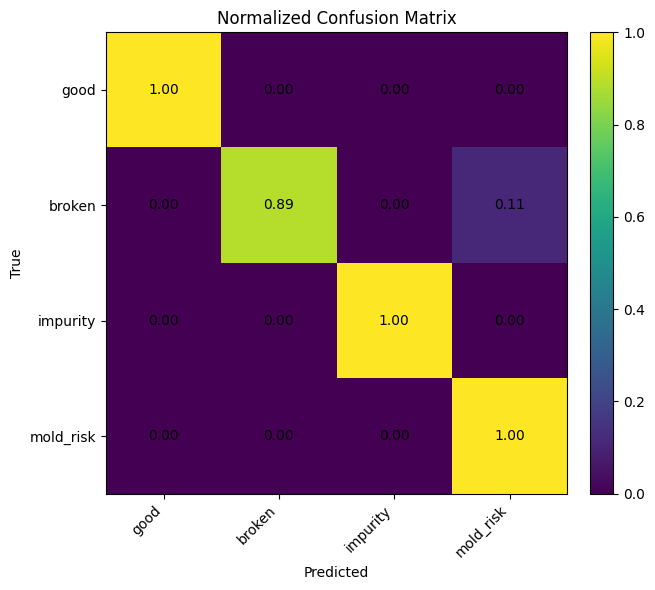

,class,precision,recall,f1-score,support
0,good,1.0,1.000000,1.000000,18.0
1,broken,1.0,0.888889,0.941176,9.0
2,impurity,1.0,1.000000,1.000000,8.0
3,mold_risk,0.9,1.000000,0.947368,9.0


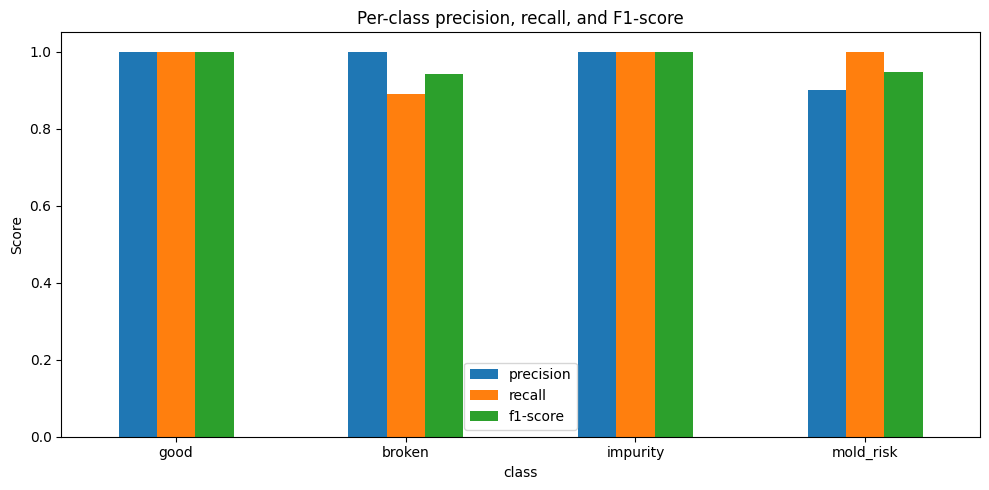

In [13]:














# ============================================================
# 10. Confusion matrices and per-class metrics
# ============================================================

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASSES))))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)
ax.set_title(f"Confusion Matrix — {MODEL_NAME} (raw argmax)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(len(CLASSES)))
ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_confusion_matrix_raw_argmax.png", dpi=180)
plt.show()

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, vmin=0, vmax=1)
ax.set_title("Normalized Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(len(CLASSES)))
ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_normalized_confusion_matrix.png", dpi=180)
plt.show()

per_class = report_df.loc[CLASSES, ["precision", "recall", "f1-score", "support"]].reset_index().rename(columns={"index": "class"})
display(per_class)
per_class.to_csv(OUTPUT_DIR / "per_class_metrics.csv", index=False)

ax = per_class.set_index("class")[["precision", "recall", "f1-score"]].plot(kind="bar", figsize=(10, 5))
ax.set_title("Per-class precision, recall, and F1-score")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_per_class_metrics.png", dpi=180)
plt.show()

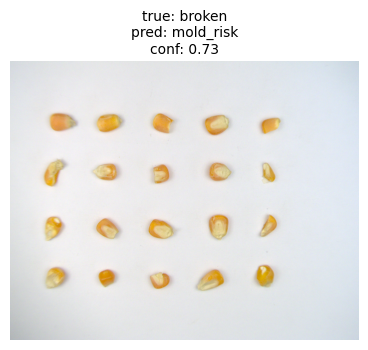

,true_label,samples,accuracy,mean_confidence,median_confidence,mean_top2_margin
0,broken,9,0.888889,0.937805,0.958276,0.888269
1,good,18,1.000000,0.978126,0.989029,0.959047
2,impurity,8,1.000000,0.999568,1.000000,0.999139
3,mold_risk,9,1.000000,0.992992,0.996688,0.987234


,true_label,pred_label,mistakes
0,broken,mold_risk,1


In [14]:
# ============================================================
# 11. Mistake visualization and confidence analysis
# ============================================================

def show_mistakes(mistakes_df, max_images=8):
    if mistakes_df.empty:
        print("No mistakes found on the test set.")
        return

    sample = mistakes_df.head(max_images)
    cols = min(4, len(sample))
    rows = math.ceil(len(sample) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"true: {row['true_label']}\npred: {row['pred_label']}\nconf: {row['confidence']:.2f}",
            fontsize=10,
        )

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "11_mistakes_raw_argmax.png", dpi=180)
    plt.show()

show_mistakes(mistakes_df)

confidence_summary = (
    pred_df.groupby("true_label")
    .agg(
        samples=("true_label", "count"),
        accuracy=("correct", "mean"),
        mean_confidence=("confidence", "mean"),
        median_confidence=("confidence", "median"),
        mean_top2_margin=("top2_margin", "mean"),
    )
    .reset_index()
)
display(confidence_summary)
confidence_summary.to_csv(OUTPUT_DIR / "confidence_summary_by_class.csv", index=False)

if not mistakes_df.empty:
    mistake_pairs = mistakes_df.groupby(["true_label", "pred_label"]).size().reset_index(name="mistakes")
    display(mistake_pairs)
    mistake_pairs.to_csv(OUTPUT_DIR / "mistake_pairs.csv", index=False)

# 12. Deployment-safe prediction rule

Official model metrics use raw argmax. The deployed app can use a safety layer. If confidence is too low or the top two probabilities are too close, the app should show **Needs review** instead of forcing a risky recommendation.

In [15]:
# ============================================================
# 12. Deployment prediction function
# ============================================================

RECOMMENDATIONS = {
    "good": {
        "risk": "Low",
        "action": "Store safely or prepare for sale",
        "recommendation": "The maize appears clean. Store in a dry place and monitor normally.",
    },
    "broken": {
        "risk": "Medium",
        "action": "Sort before storage",
        "recommendation": "Remove visibly broken or damaged kernels before storage or sale.",
    },
    "impurity": {
        "risk": "Medium",
        "action": "Clean and re-screen",
        "recommendation": "Remove foreign materials such as stones, husks, dust, or debris.",
    },
    "mold_risk": {
        "risk": "High",
        "action": "Do not store — refer for checking",
        "recommendation": "Possible mold-risk evidence needs careful checking before storage or consumption.",
    },
    "needs_review": {
        "risk": "Unclear",
        "action": "Needs review",
        "recommendation": "Capture a clearer, closer image of the maize sample on a plain surface.",
    },
}

@torch.no_grad()
def predict_image_for_deployment(image_path: Path):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    x = eval_transform(img).unsqueeze(0).to(DEVICE)
    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    best_idx = int(np.argmax(probs))
    best_label = IDX_TO_CLASS[best_idx]
    best_conf = float(probs[best_idx])

    sorted_probs = np.sort(probs)[::-1]
    top2_margin = float(sorted_probs[0] - sorted_probs[1])

    needs_review = (
        best_conf < NEEDS_REVIEW_CONFIDENCE_BELOW
        or top2_margin < NEEDS_REVIEW_TOP2_MARGIN_BELOW
    )

    final_label = "needs_review" if needs_review else best_label

    response = {
        "label": final_label,
        "raw_label": best_label,
        "confidence": round(best_conf, 4),
        "confidence_percent": round(best_conf * 100, 2),
        "top2_margin": round(top2_margin, 4),
        "needs_review": bool(needs_review),
        "probabilities": {cls: round(float(probs[i]), 4) for i, cls in IDX_TO_CLASS.items()},
        **RECOMMENDATIONS[final_label],
    }
    return response

example_path = Path(test_paths[0])
print("Example image:", example_path)
predict_image_for_deployment(example_path)

Example image: /kaggle/working/maizeguard_public_training/maizeguard_ready_dataset/test/good/ck_cnn_good_000059.tiff


{'label': 'good',
 'raw_label': 'good',
 'confidence': 0.979,
 'confidence_percent': 97.9,
 'top2_margin': 0.9625,
 'needs_review': False,
 'probabilities': {'good': 0.979,
  'broken': 0.0166,
  'impurity': 0.0,
  'mold_risk': 0.0044},
 'risk': 'Low',
 'action': 'Store safely or prepare for sale',
 'recommendation': 'The maize appears clean. Store in a dry place and monitor normally.'}

# 13. External real maize image testing

Use this for real farmer/stocker images. These images are **external demo validation**, not official training metrics unless you collect enough labeled local images.

Recommended photo rules:

1. Put shelled maize on a plain white/light surface.
2. Take the photo close enough so kernels are visible.
3. Avoid strong shadows.
4. Avoid mixing many visible conditions in one image.
5. Use one visible condition at a time: `good`, `broken`, `impurity`, or `mold_risk`.

If the image is a drying-mat photo, far-away photo, maize-on-cob photo, or mixed batch, the safe output should be **Needs review**.

In [16]:
# ============================================================
# 13. External real image test helper
# ============================================================

def find_external_test_images():
    possible_roots = []

    if KAGGLE_INPUT_ROOT.exists():
        for p in KAGGLE_INPUT_ROOT.iterdir():
            name = p.name.lower()
            if any(key in name for key in ["real", "external", "maizeguard", "farmer", "stocker"]):
                possible_roots.append(p)

    possible_roots.append(EXTERNAL_TEST_DIR)

    image_paths = []
    for root in possible_roots:
        if root.exists():
            image_paths.extend([p for p in root.rglob("*") if p.is_file() and is_image(p)])

    image_paths = sorted(set(image_paths), key=lambda p: str(p))
    return image_paths

external_images = find_external_test_images()
print(f"Found {len(external_images)} external real images.")

external_predictions = []
for p in external_images:
    try:
        pred = predict_image_for_deployment(p)
        external_predictions.append({
            "path": str(p),
            **pred,
        })
    except Exception as e:
        external_predictions.append({"path": str(p), "error": str(e)})

external_df = pd.DataFrame(external_predictions)
if not external_df.empty:
    display(external_df)
    external_df.to_csv(OUTPUT_DIR / "external_real_image_predictions.csv", index=False)

    sample = external_df.head(8)
    cols = min(4, len(sample))
    rows = math.ceil(len(sample) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.6))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, sample.iterrows()):
        try:
            img = Image.open(row["path"]).convert("RGB")
            ax.imshow(img)
            ax.set_title(
                f"{row.get('label', 'error')}\nraw: {row.get('raw_label', '')}\nconf: {row.get('confidence', '')}",
                fontsize=10,
            )
        except Exception:
            pass

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "12_external_real_predictions.png", dpi=180)
    plt.show()
else:
    print("No external real images found. Add them as a Kaggle dataset or copy them to:", EXTERNAL_TEST_DIR)

Found 0 external real images.
No external real images found. Add them as a Kaggle dataset or copy them to: /kaggle/working/maizeguard_public_training/real_external_test


# 14. Frontend/API integration guidance

Recommended deployment architecture:

```text
Next.js upload UI
      ↓
Next.js API route: /api/analyze
      ↓
FastAPI/Python model service: /predict
      ↓
PyTorch model checkpoint
      ↓
JSON result back to frontend
```

The frontend should display:

- predicted label
- confidence percentage
- risk level
- recommended action
- recommendation text
- `Needs review` when the model is uncertain

The deployed FastAPI server can use full-image-plus-tile inference. This is a lightweight alternative to the old CK-CNNLW Mask R-CNN segmentation stage and helps uploaded batch photos because the model sees both the whole image and large local crop views.


In [17]:
# ============================================================
# 14. API response example for frontend
# ============================================================

example_api_response = {
    "label": "good",
    "raw_label": "good",
    "confidence": 0.988,
    "confidence_percent": 98.8,
    "top2_margin": 0.93,
    "needs_review": False,
    "probabilities": {
        "good": 0.988,
        "broken": 0.004,
        "impurity": 0.002,
        "mold_risk": 0.006,
    },
    "risk": "Low",
    "action": "Store safely or prepare for sale",
    "recommendation": "The maize appears clean. Store in a dry place and monitor normally.",
}

print(json.dumps(example_api_response, indent=2))

{
  "label": "good",
  "raw_label": "good",
  "confidence": 0.988,
  "confidence_percent": 98.8,
  "top2_margin": 0.93,
  "needs_review": false,
  "probabilities": {
    "good": 0.988,
    "broken": 0.004,
    "impurity": 0.002,
    "mold_risk": 0.006
  },
  "risk": "Low",
  "action": "Store safely or prepare for sale",
  "recommendation": "The maize appears clean. Store in a dry place and monitor normally."
}
